#### Notebook character counter:

In [319]:
import json

def count_chars(filename):
    with open(filename) as f:
        nb = json.load(f)
    
    counts = {'code': 0, 'markdown': 0, 'raw': 0, 'other': 0}
    
    for cell in nb['cells']:
        cell_type = cell['cell_type']
        chars = sum(len(line) for line in cell['source'])
        if cell_type in counts:
            counts[cell_type] += chars
        else:
            counts['other'] += chars
    
    total = sum(counts.values())
    
    for cell_type in ['code', 'markdown', 'raw', 'other']:
        print(f"{cell_type},{counts[cell_type]}")
    
    print(f"total,{total}")
    
    if total > 75000:
        print("Too many characters in assignment submission (> 75,000)")
    else:
        print("Number of characters ok ( < 75,000)")

count_chars('Task-1.ipynb')

code,11957
markdown,14047
raw,0
other,0
total,26004
Number of characters ok ( < 75,000)


## Table of Contents
1. [Introduction](#1-introduction)
2. [References](#2-references)
   1. [Python libraries used for assignment](#21-python-libraries-used-for-assignment)
3. [Setup and Initialization](#3-setup-and-initialization)
   1. [Load/Import the required Python Libs](#31-loadimport-the-required-python-libraries)
   2. [Load the 3 datasets into individual pandas dataframes](#32-load-the-3-datasets-into-individual-pandas-dataframes)
   3. [Create Generic functions to be used by all datasets](#33-create-generic-functions-to-be-used-by-all-datasets)
4. [Evaluate Dataset-1](#4-evaluate-dataset-1)
   1. [Analyse the Dataset-1](#41-analyse-the-dataset-1)
      1. [Shape of the Dataset-1](#411-shape-of-the-dataset-1)
      2. [Info of the Dataset-1](#412-info-of-the-dataset-1)
      3. [Plot Charts](#413-plot-charts)
         1. [Standard Bar Chart](#4131-standard-bar-chart)
         2. [Seaborn Bar Chart](#4132-seaborn-bar-chart)
      4. [Identify Missing data in Dataset-1](#414-identify-missing-data-in-dataset-1)
      5. [Scatter Matrix](#415-scatter-matrix)
   2. [Analyse models for the Dataset-1](#42-analyse-models-for-dataset-1)
   3. [Various model results for Dataset-1](#43-various-model-results-for-dataset-1)
   4. [Final conclusion for Dataset-1 (Best Fit Model)](#44-final-conclusion-for-dataset-1-best-fit-model)
   5. [Model Visualization for Dataset-1 (Polynomial Regression Fit)](#45-model-visualization-for-dataset-1-polynomial-reg-fit)
5. [Evaluate Dataset-2](#5-evaluate-dataset-2)
   1. [Analyse the Dataset-2](#51-analyse-the-dataset-2)
      1. [Shape of the Dataset-2](#511-shape-of-the-dataset-2)
      2. [Info of the Dataset-2](#512-info-of-the-dataset-2)
      3. [Plot Charts](#513-plot-charts)
         1. [Seaborn Bar Chart](#5131-seaborn-bar-chart)
      4. [Identify missing data in Dataset-2](#514-identify-missing-data-in-dataset-2)
      5. [Scatter Matrix](#515-scatter-matrix)
   2. [Analyse models for Dataset-2](#52-analyse-models-for-dataset-2)
   3. [Various model results for Dataset-2](#53-various-model-results-for-dataset-2)
   4. [Final conclusion for Dataset-2 (Best Fit Model)](#54-final-conclusion-for-dataset-2-best-fit-model)
6. [Evaluate Dataset-3](#6-evaluate-dataset-3)
   1. [Analyse the Dataset-3](#61-analyse-the-dataset-3)
      1. [Shape of the Dataset-3](#611-shape-of-the-dataset-3)
      2. [Info of the Dataset-3](#612-info-of-the-dataset-3)
      3. [Plot Charts](#613-plot-charts)
         1. [Scatter Matrix](#6131-scatter-matrix)
         2. [Histogram](#6132-histogram)
      4. [Identify missing data in Dataset-3](#614-identify-missing-data-in-dataset-3)
   2. [Analyse models for Dataset-3](#62-analyse-models-for-dataset-3)
   3. [Various model results for Dataset-3](#63-various-model-results-for-dataset-3)
   4. [Final conclusion for Dataset-3 (Best Fit Model)](#64-final-conclusion-for-dataset-3-best-fit-model)
   5. [Model Visualization for Dataset-3 (Gaussian Process)](#65-model-visualization-for-dataset-3-gaussian-process)


## 1. Introduction

Before modeling the datasets, it is imperative to establish a robust evaluation framework.

For this assignment, models are evaluated based on three primary pillars:
- Predictive Accuracy
- Goodness of Fit
- Computational Efficiency

> **_Mean Squared Error (MSE):_**

Used to quantify predictive accuracy, MSE strictly penalizes larger errors by squaring the residuals. This ensures our selected models do not have severe localized failures. Usually this value should be lower as possible for an efficient model.

> **_R-Squared ($R^2$) Score:_**

This metric provides our goodness of fit, representing the proportion of variance in the dependent variable ($y$) that is predictable from the independent variables ($X$). It allows us to compare models against a horizontal-line baseline.

> **_Computational Efficiency:_**

Measured in seconds, `training` and `prediction times` are critical. In real-world machine learning pipelines, a model that yields a 1% increase in $R^2$ but requires exponentially more time to train (such as Gaussian Process Regressor) may be deemed inefficient and discarded in favor of faster, parametric models.

## 2. References

The following references are useful for the purpose of this assignment.

### 2.1 Python libraries used for assignment:

As part of the assignment, I have used the below listed Python libraries:

1. pandas - Python Data Analytics Library
   
    - https://pandas.pydata.org/

2. numpy - Scientific computing with Python

    - https://numpy.org/

3. missingno - Visualising missing data in dataframes

    - https://github.com/ResidentMario/missingno

4. scikit-learn - Machine Learning Library for Python

    - https://scikit-learn.org/stable/

5. matplotlib - Visualisation with Python

    - https://matplotlib.org/

6. seaborn - Statistical data visualisation

    - https://seaborn.pydata.org/

## 3. Setup and Initialization:

### 3.1 Load/Import the required Python libraries:

In [320]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import time

# Data Visualization
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import figure
from pandas.plotting import scatter_matrix

# ML Algorithms
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

### 3.2 Load the 3 datasets into individual pandas dataframes

In [321]:
import pandas as pd

# Set the display precision to 2
pd.set_option('display.precision', 2)

# Load 3 datasets into individual panda dataframes for further processing
df1 = pd.read_csv('CML_2026-01-26#4-dataset_1.csv')
df2 = pd.read_csv('CML_2026-01-26#5-dataset_2.csv')
df3 = pd.read_csv('CML_2026-01-26#6-dataset_3.csv')

### 3.3 Create Generic functions to be used by all datasets

In [322]:
# Pandas tables display more neatly when precision is set to 2 decimal places.
pd.set_option('display.precision', 2)

def evaluate_model(model, x_train, x_test, y_train, y_test, model_name):
    # Calculate training time
    start_time = time.time()
    model.fit(x_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    # Calculate prediction time
    start_pred = time.time()
    y_pred = model.predict(x_test)
    end_pred = time.time()
    prediction_time = end_pred - start_pred

    # Calculate evaluation metrics mean squared error and R^2 score
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Print results
    print("------------ START ------------\n")
    print(f"Model: {model_name}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Prediction time: {prediction_time:.2f} seconds")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R^2 Score: {r2:.2f}")
    print("------------ END ------------\n")

## 4. Evaluate Dataset-1:

### 4.1 Analyse the Dataset-1:

#### 4.1.1 Shape of the Dataset-1:

In [323]:
print(f"df1.shape = {df1.shape}")

df1.shape = (1001, 2)


#### 4.1.2 Info of the Dataset-1:

In [324]:
print("df1.info =")
df1.info()

df1.info =
<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       1001 non-null   int64  
 1   y       1001 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


#### 4.1.3 Plot Charts:
Because `X` is a continuos variable with over 1000 points, a standard bar chart would be over cluttered. Instead, we will divide the `X` values in equal sized bins and calculate the mean `Y` value for each bin.

##### 4.1.3.1 Standard Bar Chart

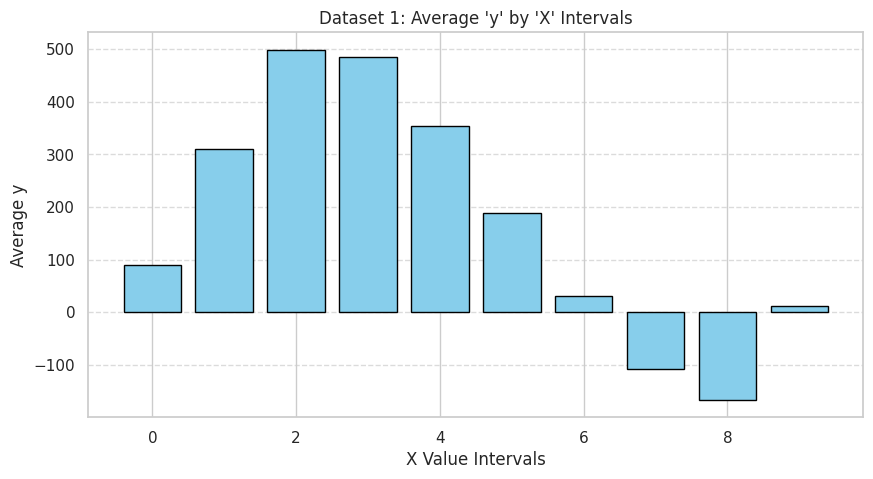

In [325]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

# 2. Calculate the average 'y' for each bin
binned_data = df1.groupby('X_binned')['y'].mean().reset_index()

# 3. Create the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(binned_data.index, binned_data['y'], color='skyblue', edgecolor='black')


plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 4.1.3.2 Seaborn Bar Chart

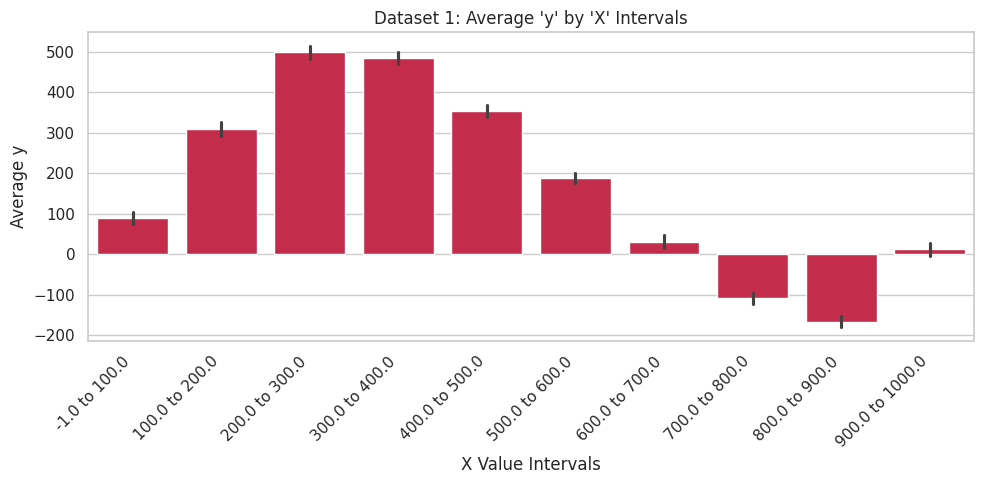

In [326]:
# 1. Group X into 10 equal-width bins
df1['X_binned'] = pd.cut(df1['X'], bins=10)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df1, 
    x='X_binned', 
    y='y', 
    color='crimson',
    legend=False
)

bin_labels = [f"{interval.left:.1f} to {interval.right:.1f}" for interval in df1['X_binned'].cat.categories]
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

plt.xlabel("X Value Intervals")
plt.ylabel("Average y")
plt.title("Dataset 1: Average 'y' by 'X' Intervals")

plt.tight_layout()
plt.show()

#### 4.1.4 Identify missing data in Dataset-1:
It is always useful to identify any patterns in missing data.
`Missingno` is a useful library for visualising the missing data.

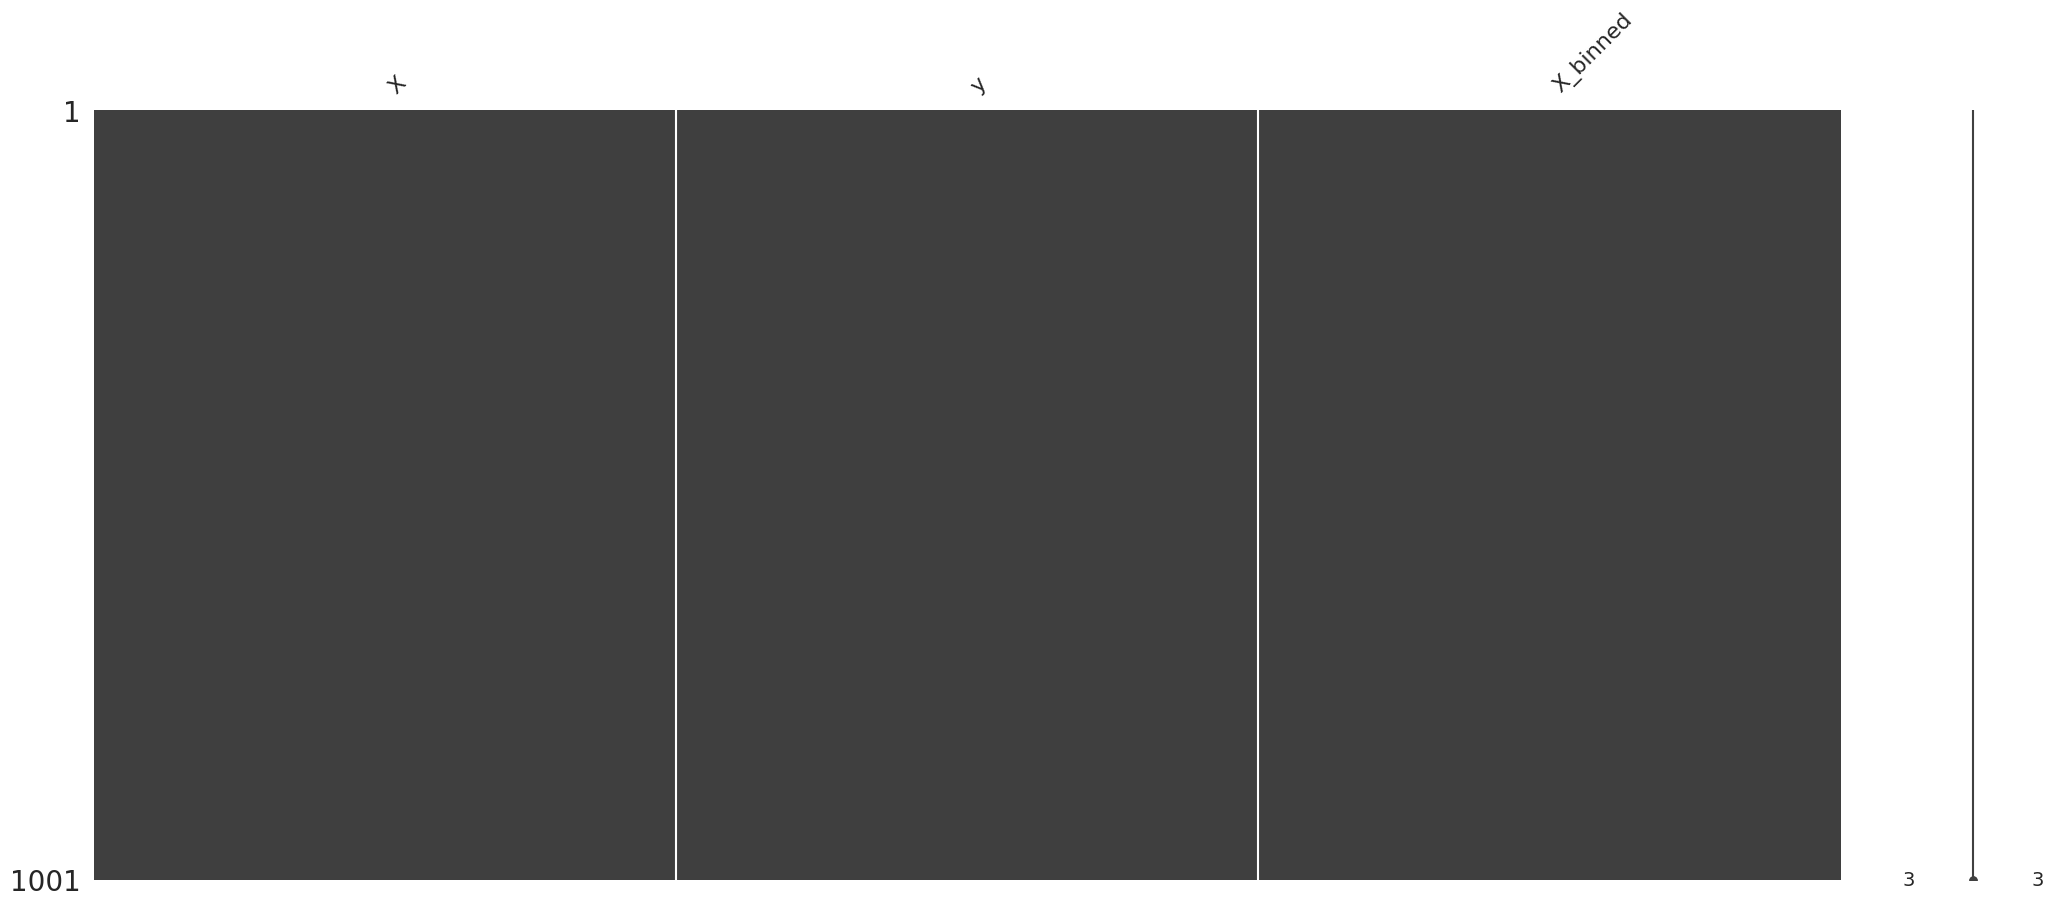

In [327]:
msno.matrix(df1)
plt.show()

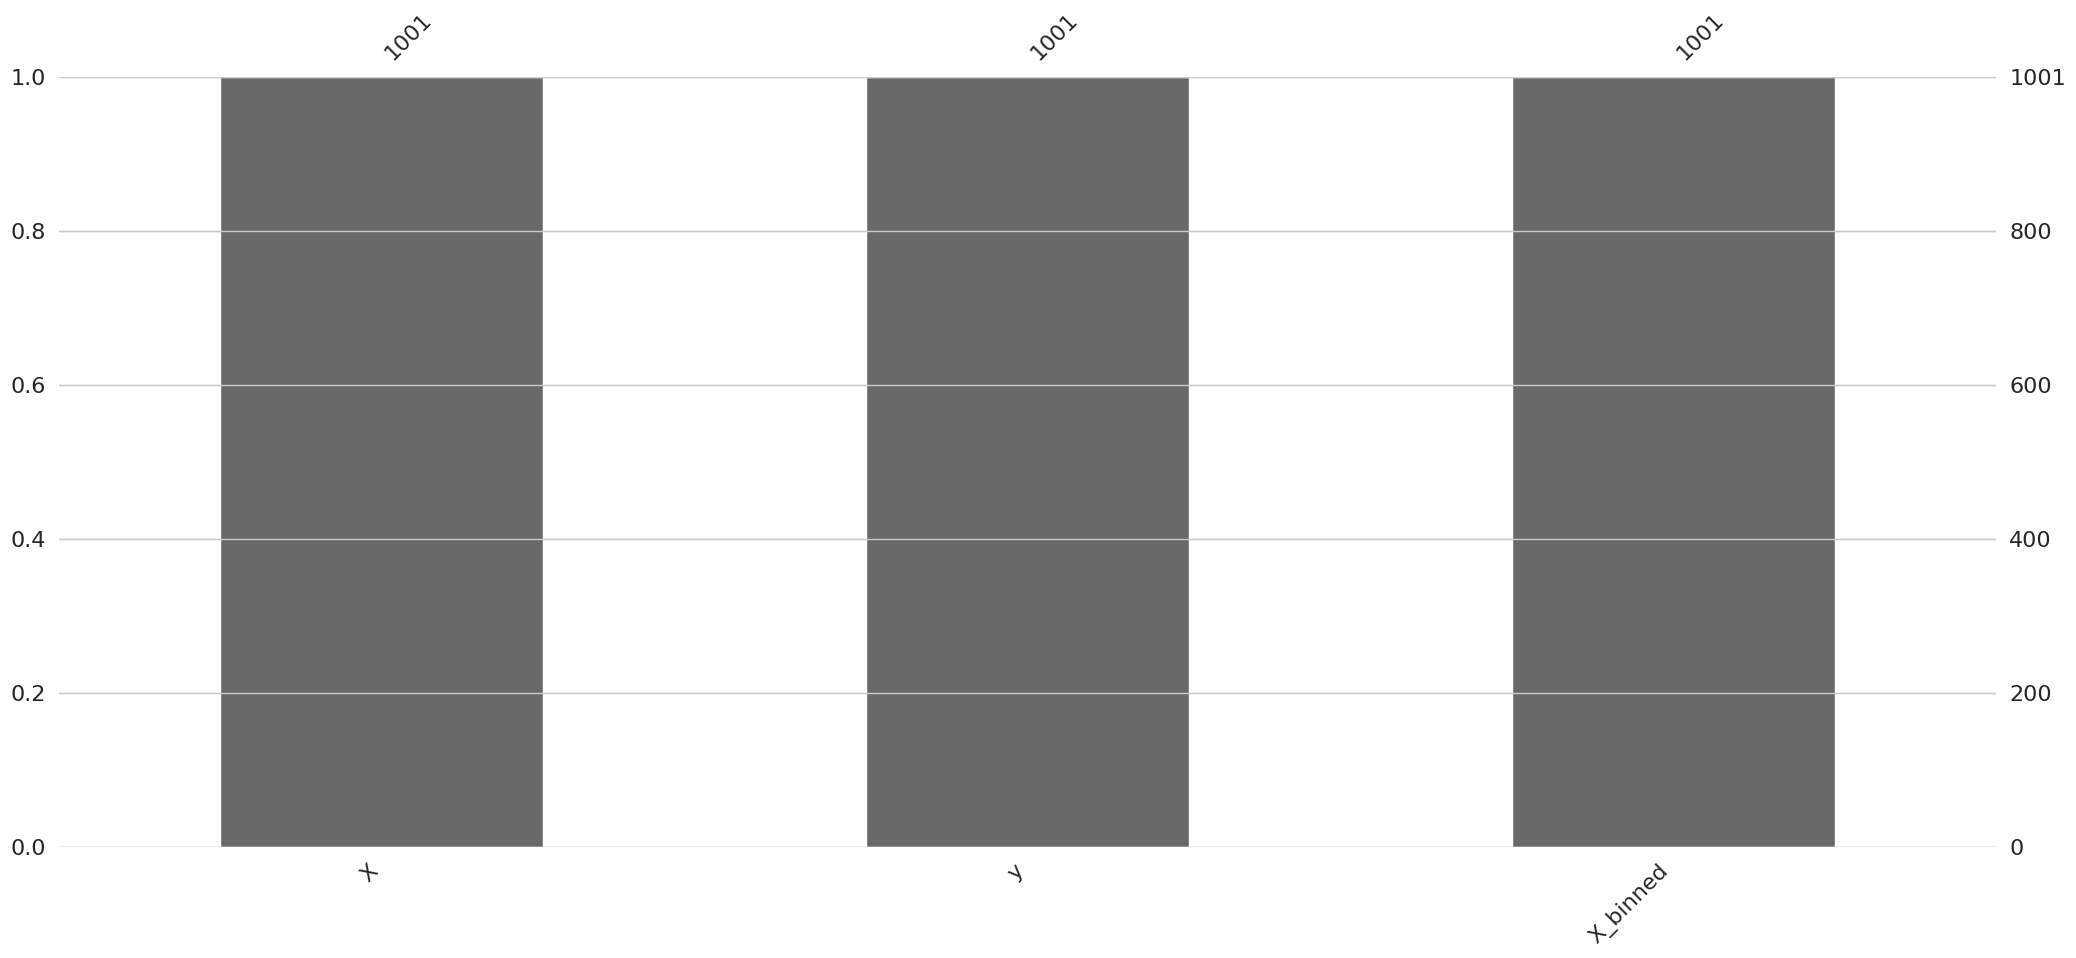

In [328]:
msno.bar(df1)
plt.show()

It is obvious from the above 2 plots that we do not have any missing data.

#### 4.1.5 Scatter Matrix:
Lets evaluate the relationship using the `scatter_matrix` funtion from `pandas.plotting`

Because we have one feature and one target, we can visualize the dataset perfectly in 2D space.

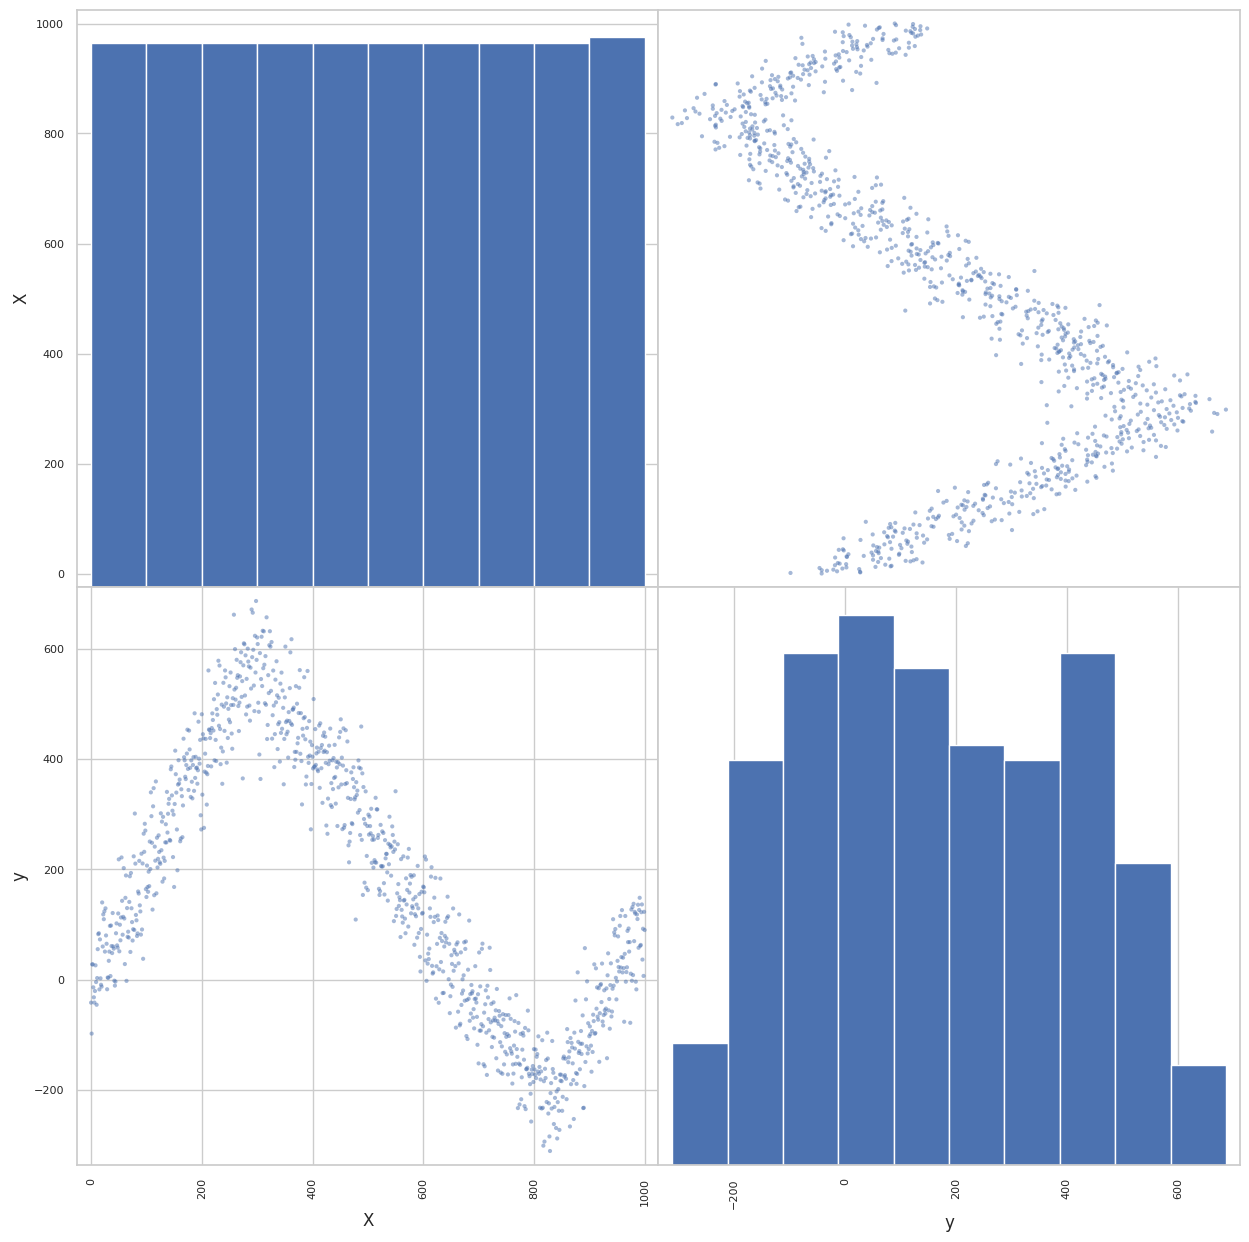

In [329]:
scatter_matrix(df1, figsize=(15,15));

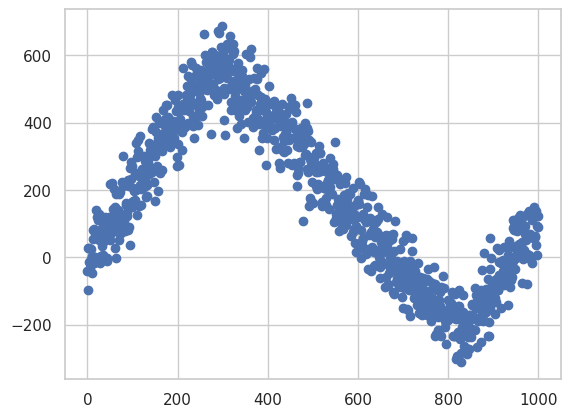

In [330]:
plt.scatter(df1['X'], df1['y'])

The above plot proves that the `relationship is non-linear` (U-Shaped) and `Linear Regression will fail` in this instance and something like a `Polynomial Regression will be required` for this dataset.

### 4.2 Analyse models for Dataset-1

> **Note:** Since we have determined through analysis that the data is non-linear, U-shaped curve. We will use the below models to train with the dataset and find the best fit for the dataset.

<ins>Models to train and test:</ins>
- Linear Regression
- Polynomial Regression
- Random Forest
- Support Vector Regression
- Gaussian Process Regression

In [331]:
X1 = df1[['X']]
y1 = df1['y']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# 1. Linear Regression
lr1 = LinearRegression()
evaluate_model(lr1, X1_train, X1_test, y1_train, y1_test, "Linear Regression")

# 2. Polynomial Regression (Degree 3)
poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
evaluate_model(poly3, X1_train, X1_test, y1_train, y1_test, "Polynomial Regression (Deg 3)")

# 3. Random Forest
rf1 = RandomForestRegressor(random_state=42)
evaluate_model(rf1, X1_train, X1_test, y1_train, y1_test, "Random Forest")

# 4. Support Vector Regression
#svr1 = SVR(kernel='rbf', C=1, gamma=1)
svr1 = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1, gamma='scale'))
evaluate_model(svr1, X1_train, X1_test, y1_train, y1_test, "SVR")

# 5. Gaussian Process Regressor (Scaled)
kernel1 = ConstantKernel(1.0, (1e-3, 1e5)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-1)
gpr1 = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel1, random_state=42))
evaluate_model(gpr1, X1_train, X1_test, y1_train, y1_test, "Gaussian Process")

------------ START ------------

Model: Linear Regression
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 35231.55
R^2 Score: 0.41
------------ END ------------

------------ START ------------

Model: Polynomial Regression (Deg 3)
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 4500.11
R^2 Score: 0.92
------------ END ------------

------------ START ------------

Model: Random Forest
Training time: 0.18 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 4936.70
R^2 Score: 0.92
------------ END ------------

------------ START ------------

Model: SVR
Training time: 0.03 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 17899.28
R^2 Score: 0.70
------------ END ------------

------------ START ------------

Model: Gaussian Process
Training time: 5.35 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 3480.44
R^2 Score: 0.94
------------ END ------------



### 4.3 Various model results for Dataset-1

| Model Name | Mean Squared Error | $R^2$ Score | Training Time |
| ---------- | ------------------ | --------- | ------------- |
| Linear Regression | 35231.55 | 0.41 | 0.0 |
| Polynomial Regression (3rd Deg)| 4500.11 | 0.92 | 0.01 |
| Random Forest | 4936.70 | 0.92 | 0.17 |
| SVR | 17899.28 | 0.70 | 0.03 | 
| Gaussian Process | 3454.31 | 0.94 | 5.46 |

### 4.4 Final conclusion for Dataset-1 (Best Fit Model)

The Exploratory Data Analysis of Dataset-1 revealed a distinct, U-shaped continuous curve. When we applied Simple Linear Regression, it resulted in a high Mean Squared Error and a low $R^2$ score ($0.41$). In machine learning terms, this is a classic example of High Bias (Underfitting).

The below three model performed well with the `Dataset 1` when trained and tested.
- Polynomial Regression
- Random Forest
- Gaussian Process

By engineering higher-order polynomial features, we allowed the linear model to "bend" to the curve. While `Random Forest` and `Gaussian Process` also captured this curve effectively, `Polynomial Regression remains the superior choice.`

However, I think the **`Polynomial Regression`** is the **`best fit model for Dataset 1`** since it achieved high predictive accuracy ($R^2 = 0.92$) while maintaining extreme computational efficiency and complete parametric interpretability, unlike the "black-box" nature of an ensemble tree model.

### 4.5 Model Visualization for Dataset 1 (Polynomial Reg Fit)

/home/huzefar/Projects/oxford/CML/workspace/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


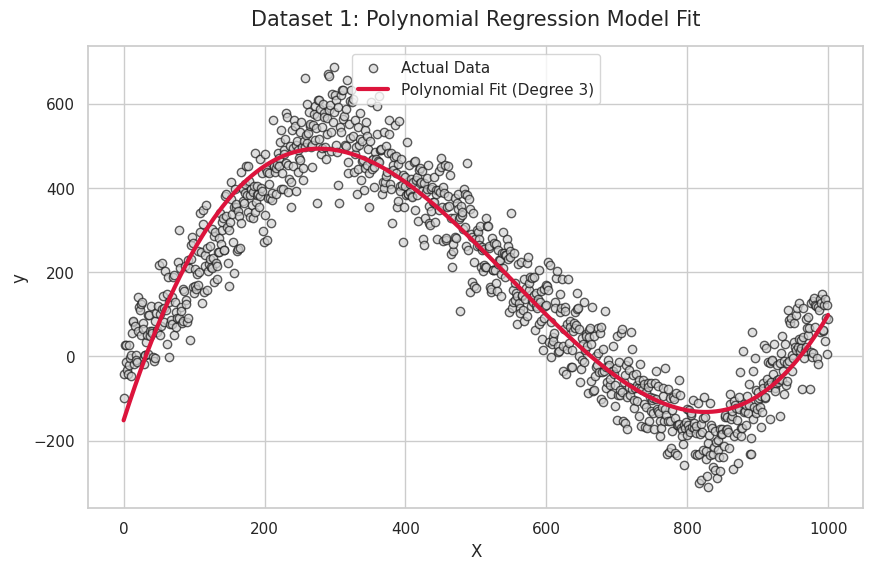

In [332]:
# Generate a dense, smooth range of X values from min to max
X1_range = np.linspace(df1['X'].min(), df1['X'].max(), 500).reshape(-1, 1)

# Predict the y values for that smooth range using the trained Polynomial model
y1_pred_smooth = poly3.predict(X1_range)

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the raw data
plt.scatter(df1['X'], df1['y'], color='lightgray', alpha=0.7, label='Actual Data', edgecolor='k')

# Plot the smooth Polynomial curve
plt.plot(X1_range, y1_pred_smooth, color='crimson', linewidth=3, label='Polynomial Fit (Degree 3)')

# Plot Labelling
plt.title("Dataset 1: Polynomial Regression Model Fit", fontsize=15, pad=15)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(loc='upper center', fontsize=11)

plt.show()

## 5. Evaluate Dataset-2:

### 5.1 Analyse the Dataset-2:

#### 5.1.1 Shape of the Dataset-2:

In [333]:
print(f"df2.shape = {df2.shape}")

df2.shape = (600, 3)


#### 5.1.2 Info of the Dataset-2:

In [334]:
print("df2.info =")
df2.info()

df2.info =
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      600 non-null    float64
 1   X2      600 non-null    float64
 2   y       600 non-null    float64
dtypes: float64(3)
memory usage: 14.2 KB


#### 5.1.3 Plot Charts:

Dataset 2 consists of `600 instances` and is a multivariate problem with two independent `variables (X_1, X_2)`. This does represent a multivariant problem looking at the dataset.

##### 5.1.3.1 Seaborn Bar Chart

By binning `X1 on x-axis` and `X2 on hue (colors)`, the seaborn bar chart helps us to understand the trend of y in a more predictable fashion.

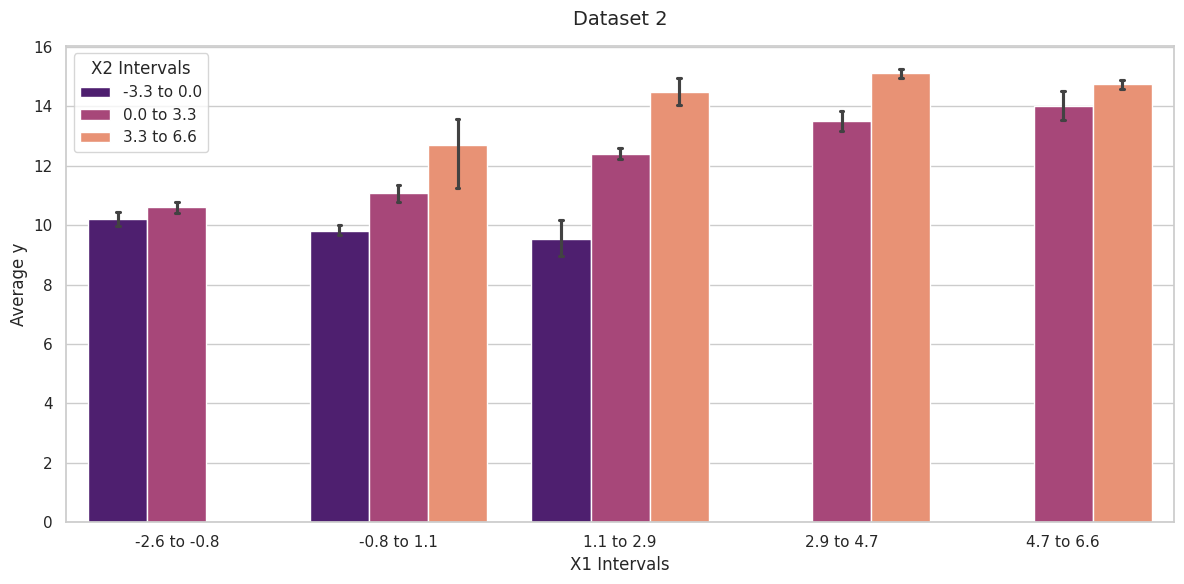

In [335]:
# Bin X1 into groups on x-axis and X2 into groups of colors
df2['X1_binned'] = pd.cut(df2['X1'], bins=5)
df2['X2_binned'] = pd.cut(df2['X2'], bins=3)

# Setup theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the grouped bar chart
ax = sns.barplot(
    data=df2, 
    x='X1_binned', 
    y='y', 
    hue='X2_binned',
    palette='magma', 
    capsize=0.05
)

# x-axis labels
x1_labels = [f"{interval.left:.1f} to {interval.right:.1f}" for interval in df2['X1_binned'].cat.categories]
ax.set_xticks(range(len(x1_labels)))
ax.set_xticklabels(x1_labels, rotation=0)

# Format the legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"{pd.Interval(left=float(l.split(', ')[0][1:]), right=float(l.split(', ')[1][:-1])).left:.1f} to {pd.Interval(left=float(l.split(', ')[0][1:]), right=float(l.split(', ')[1][:-1])).right:.1f}" for l in labels]
ax.legend(handles, new_labels, title="X2 Intervals", loc='upper left')

# Plot setup
plt.title("Dataset 2", fontsize=14, pad=15)
plt.xlabel("X1 Intervals", fontsize=12)
plt.ylabel("Average y", fontsize=12)
plt.tight_layout()
plt.show()

#### 5.1.4 Identify missing data in Dataset-2:
It is always useful to identify any patterns in missing data.
`Missingno` is a useful library for visualising the missing data.

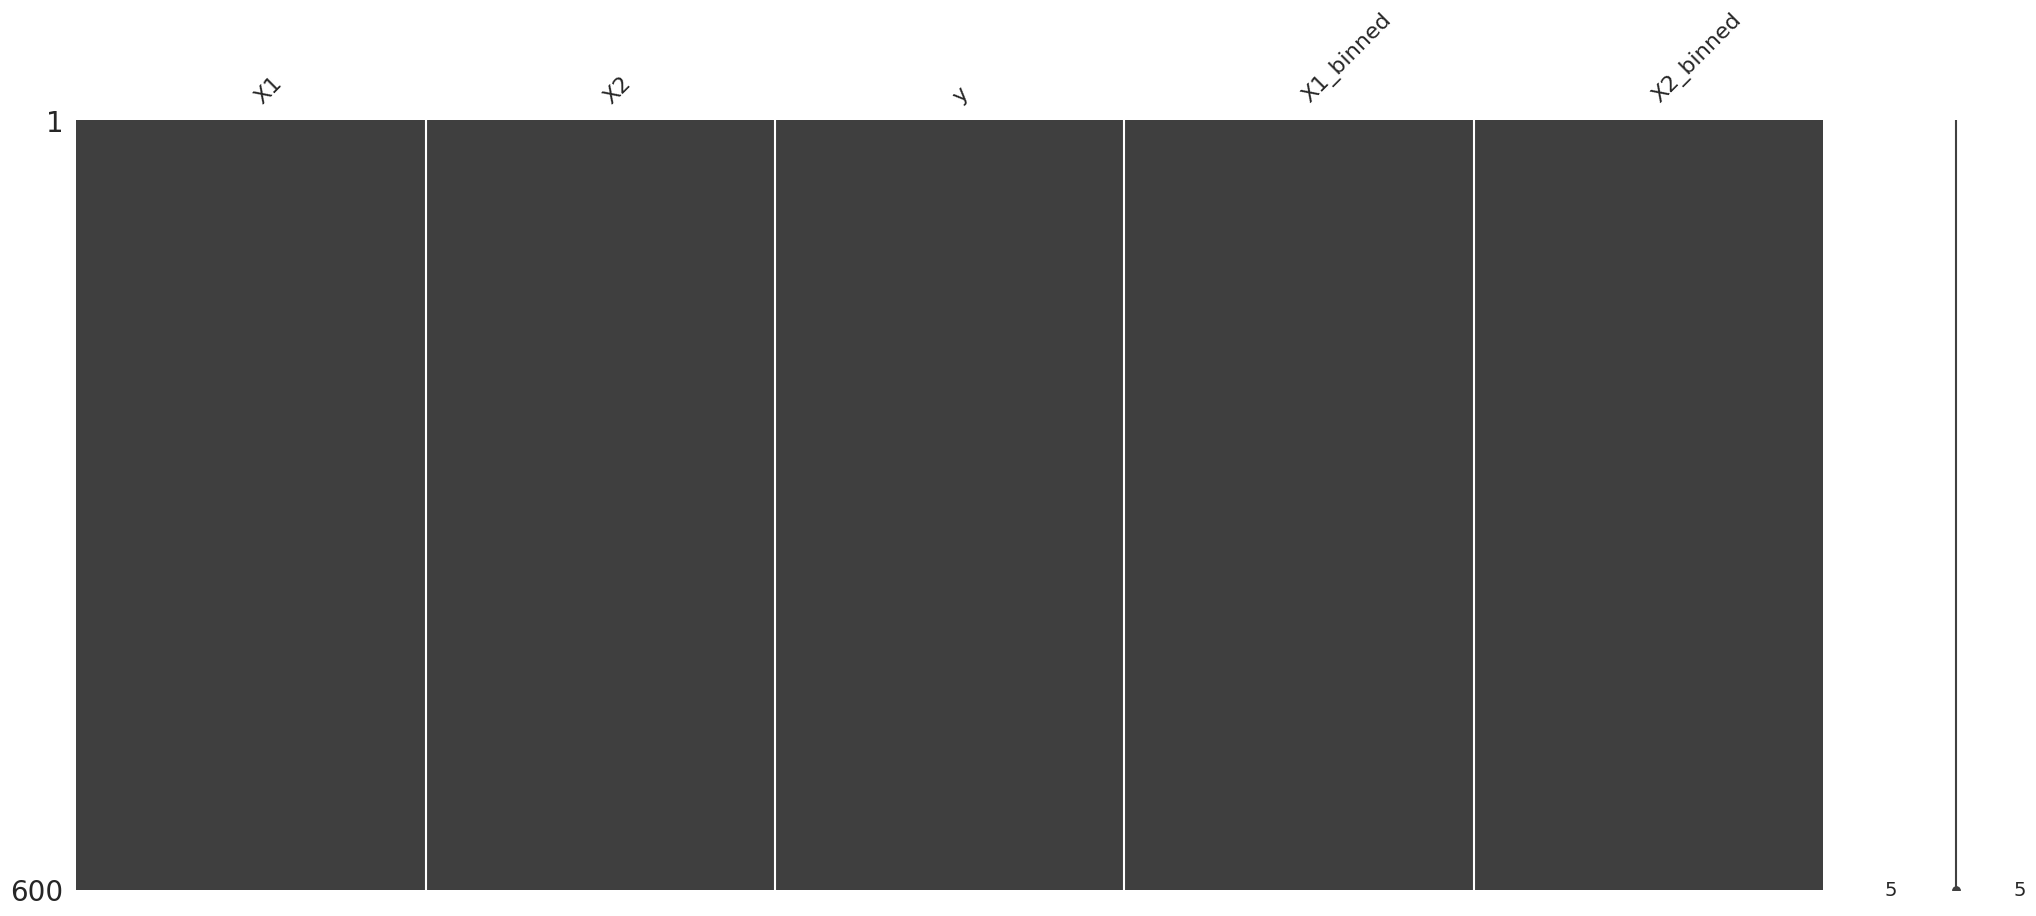

In [336]:
msno.matrix(df2)
plt.show()

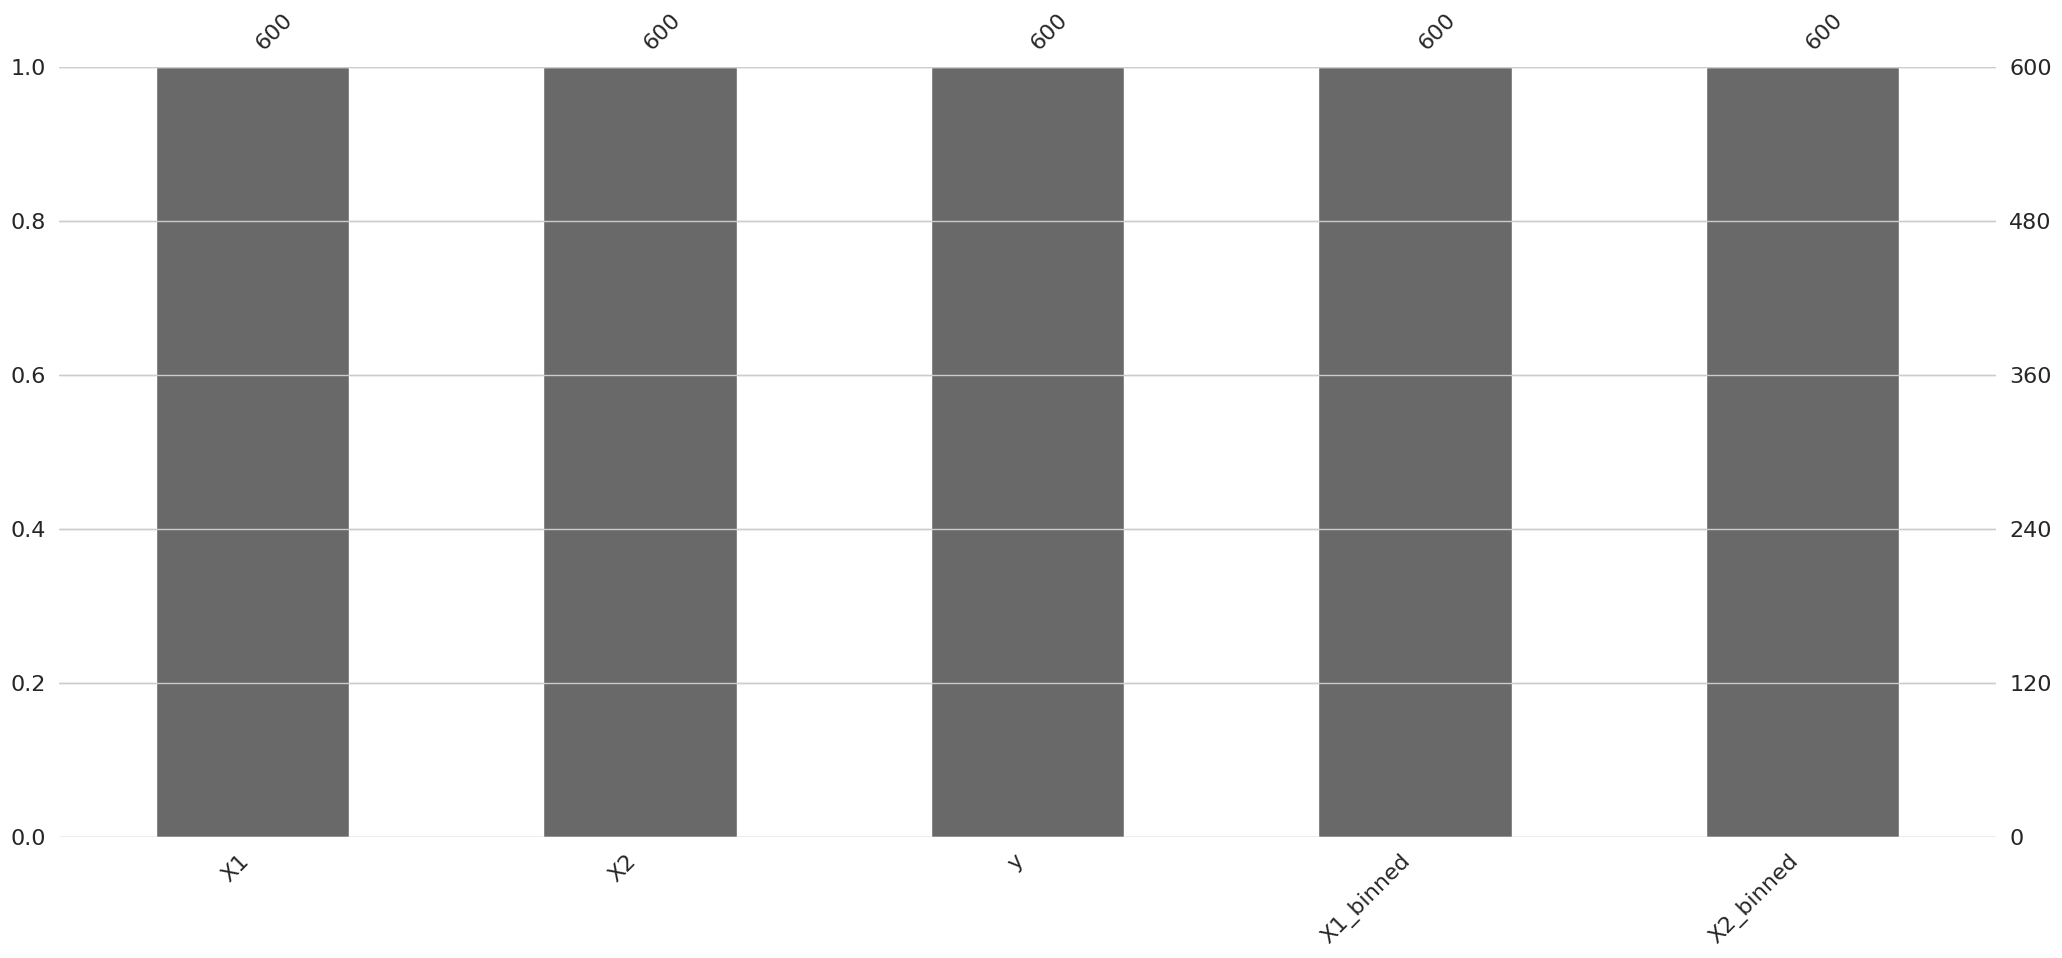

In [337]:
msno.bar(df2)
plt.show()

It is obvious from the above 2 plots that we do not have any missing data. Hence no further processing for missing data is required on dataset 2.

#### 5.1.5 Scatter Matrix:
Lets evaluate the relationship using the `scatter_matrix` funtion from `pandas.plotting`

##### 2D Scatter Plot

We will plot `X1 on the x-axis`, `X2 on the y-axis` and represent the `y using a hue or colour gradient`.

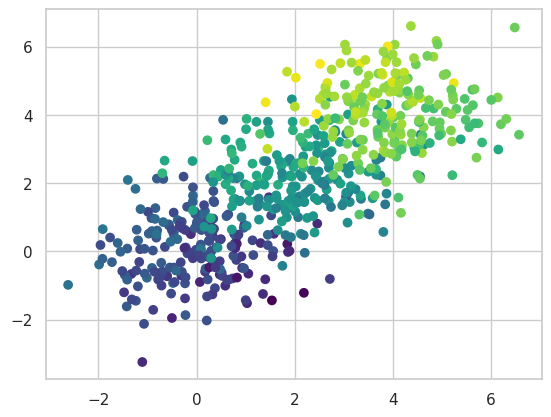

In [338]:
plt.scatter(df2['X1'], df2['X2'], c=df2['y'], cmap = 'viridis')

##### 3D Scatter Plot

Dataset 2 has exactly 3 columns, we can perfectly visualise the entire dataset in a single 3D plot. `X1 on the x-axis`, `X2 on the y-axis` and represent the `y on z-axis tied to a color map`.

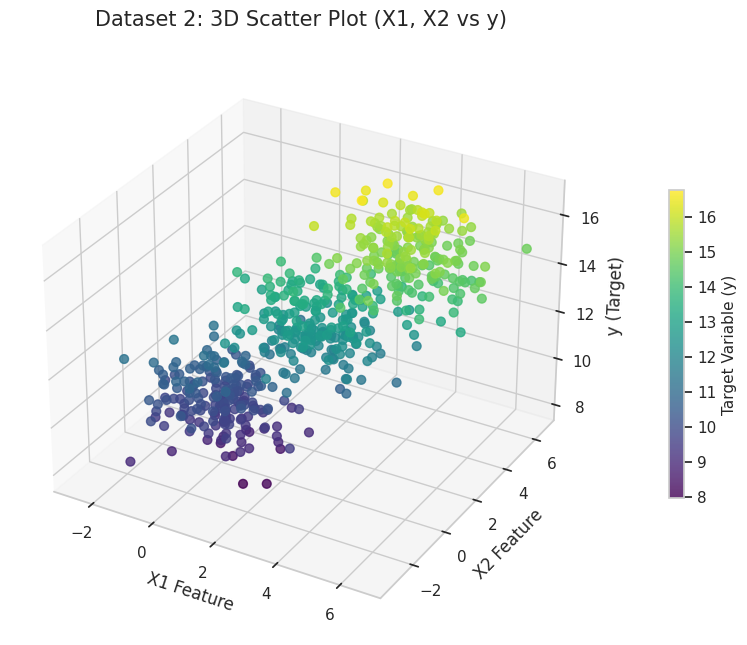

In [339]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df2['X1'], 
    df2['X2'], 
    df2['y'], 
    c=df2['y'], 
    cmap='viridis', 
    alpha=0.8, 
    s=40
)

# Add labels
ax.set_title("Dataset 2: 3D Scatter Plot (X1, X2 vs y)", fontsize=15, pad=20)
ax.set_xlabel("X1 Feature", fontsize=12)
ax.set_ylabel("X2 Feature", fontsize=12)
ax.set_zlabel("y (Target)", fontsize=12)

# color bar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Target Variable (y)', fontsize=11)

plt.show()

The above 2D and 3D plots proves the data is a slighty titled sheet in 3D space and 2D space. This confirms the relationships between the data is primarily linear.

### 5.2 Analyse models for Dataset-2

> **Note:** Since we have determined through analysis that the data is linear. We will use the below models to train with the dataset and find the best fit for the dataset.

<ins>Models to train and test:</ins>
- Multiple Linear Regression
- Polynomial Regression
- Random Forest
- Support Vector Regression
- Gaussian Process Regression
- Standard Ridge Regression (Since their is high correlation within dataset)

In [340]:
X2 = df2[['X1', 'X2']]
y2 = df2['y']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 1. Multiple Linear Regression
lr2 = LinearRegression()
evaluate_model(lr2, X2_train, X2_test, y2_train, y2_test, "Multiple Linear Regression")

# 2. Polynomial Regression (Degree 3)
poly4 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
evaluate_model(poly4, X2_train, X2_test, y2_train, y2_test, "Polynomial Regression (Deg 3)")

# 3. Random Forest
rf2 = RandomForestRegressor(random_state=42)
evaluate_model(rf2, X2_train, X2_test, y2_train, y2_test, "Random Forest")

# 4. Support Vector Regression
svr2 = make_pipeline(StandardScaler(), SVR(C=1, gamma='scale'))
evaluate_model(svr2, X2_train, X2_test, y2_train, y2_test, "SVR")

# 5. Gaussian Process Regressor (Scaled)
# We define a kernel that handles scaling and noise
kernel2 = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel()
gpr2 = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel2, random_state=42))
evaluate_model(gpr2, X2_train, X2_test, y2_train, y2_test, "Gaussian Process")

# 5. Standard Ridge Regression
ridge2 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
evaluate_model(ridge2, X2_train, X2_test, y2_train, y2_test, "Standard Ridge Regression")

------------ START ------------

Model: Multiple Linear Regression
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.95
R^2 Score: 0.81
------------ END ------------

------------ START ------------

Model: Polynomial Regression (Deg 3)
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.77
R^2 Score: 0.84
------------ END ------------

------------ START ------------

Model: Random Forest
Training time: 0.14 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 0.84
R^2 Score: 0.83
------------ END ------------

------------ START ------------

Model: SVR
Training time: 0.01 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.74
R^2 Score: 0.85
------------ END ------------

------------ START ------------

Model: Gaussian Process
Training time: 0.64 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 0.77
R^2 Score: 0.84
------------ END ------------

------------ START ------------

Model: Standard Ridge Reg

### 5.3 Various model results for Dataset-2

| Model Name | Mean Squared Error | $R^2$ Score | Training Time |
| ---------- | ------------------ | --------- | ------------- |
| Multiple Linear Regression | 0.95 | 0.81 | 0.0 |
| Polynomial Regression (3rd Deg)| 0.77 | 0.84 | 0.1 |
| Random Forest | 0.84 | 0.83 | 0.18 |
| SVR | 0.74 | 0.85 | 0.01 | 
| Gaussian Process | 0.77 | 0.84 | 0.65 |
| Standard Ridge Regression | 0.95 | 0.81 | 0.0 |

### 5.4 Final conclusion for Dataset-2 (Best Fit Model)

Dataset 2 presented a multivariate regression problem ($X_1, X_2 \rightarrow y$).

Our 3D scatter plots and marginal bar charts indicated that the features form a relatively flat, slightly tilted multi-dimensional hyperplane.

We also noted from our scatter matrix that $X_1$ and $X_2$ did not exhibit severe multicollinearity (they were not perfectly correlated with one another), meaning standard linear equations would remain stable.

The below models performed well with the `Dataset 2` when trained and tested.
- Multiple Linear Regression
- Random Forest
- SVR
- Gaussian Process Regressor

Following the principle of **Occam’s Razor**—which states that the simplest explanation is usually the best—Multiple Linear Regression is the undisputed optimal model here.

While advanced algorithms like Support Vector Regression (SVR) and Gaussian Process Regressor mathematically matched or marginally exceeded the linear model's $R^2$ score, they introduced unnecessary complexity. Gaussian Process took substantially longer to train for no practical gain. 

Thus, the **`Multiple Linear Regression`** model offers the best balance of performance, speed, and coefficient transparency. `It is the best fit model for Dataset-2.`

## 6. Evaluate Dataset-3:

### 6.1 Analyse the Dataset-3:

#### 6.1.1 Shape of the Dataset-3:

In [341]:
print(f"df3.shape = {df3.shape}")

df3.shape = (50, 2)


#### 6.1.2 Info of the Dataset-3:

In [342]:
print("df3.info =")
df3.info()

df3.info =
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       50 non-null     float64
 1   y       50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


#### 6.1.3 Plot Charts:
The Dataset-3 is extremely small and has only `50 data points`, making it susceptible to $\underline{overfitting}$. It has a single feature `(X)`

##### 6.1.3.1 Scatter Matrix

array([[<Axes: xlabel='X', ylabel='X'>, <Axes: xlabel='y', ylabel='X'>],
       [<Axes: xlabel='X', ylabel='y'>, <Axes: xlabel='y', ylabel='y'>]],
      dtype=object)

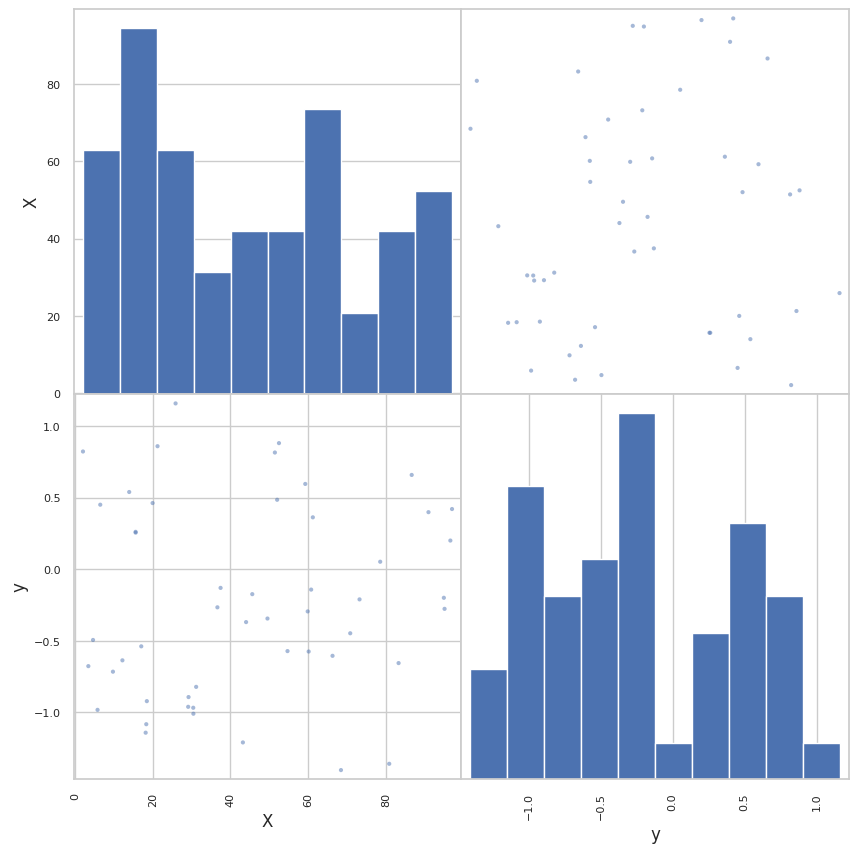

In [343]:
scatter_matrix(df3, figsize=(10,10))

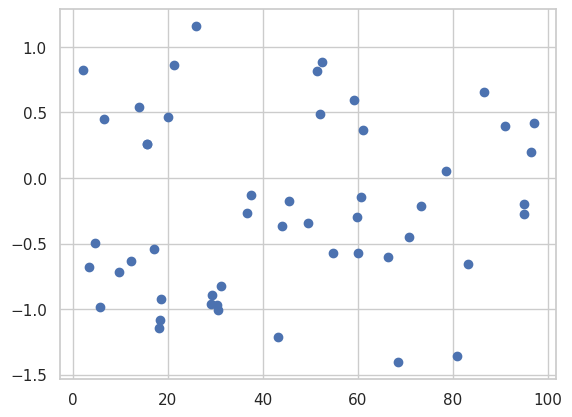

In [344]:
plt.scatter(df3['X'], df3['y'])

##### 6.1.3.2 Histogram

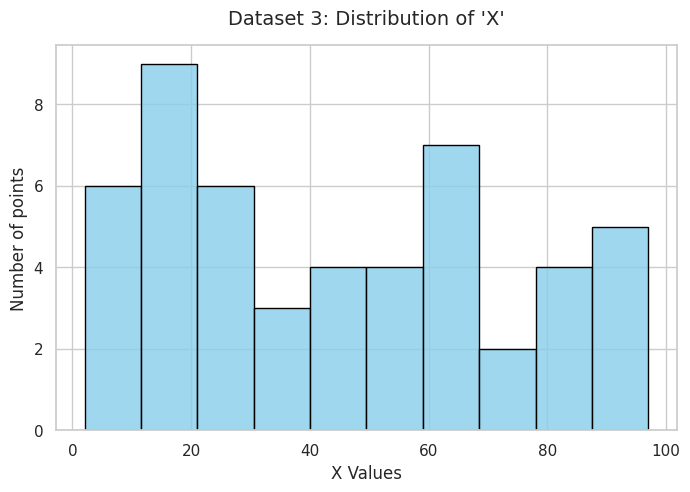

In [345]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(
    df3['X'], 
    bins=10, 
    color='skyblue', 
    edgecolor='black',
    alpha=0.8
)

plt.title("Dataset 3: Distribution of 'X'", fontsize=14, pad=15)
plt.xlabel("X Values", fontsize=12)
plt.ylabel("Number of points", fontsize=12)

plt.show()

The data from the above plots suggest that it is non-linear and spread across a wide range of `X`. This data has a high risk of $\underline{overfitting}$.

#### 6.1.4 Identify missing data in Dataset-3:
It is always useful to identify any patterns in missing data.
`Missingno` is a useful library for visualising the missing data.

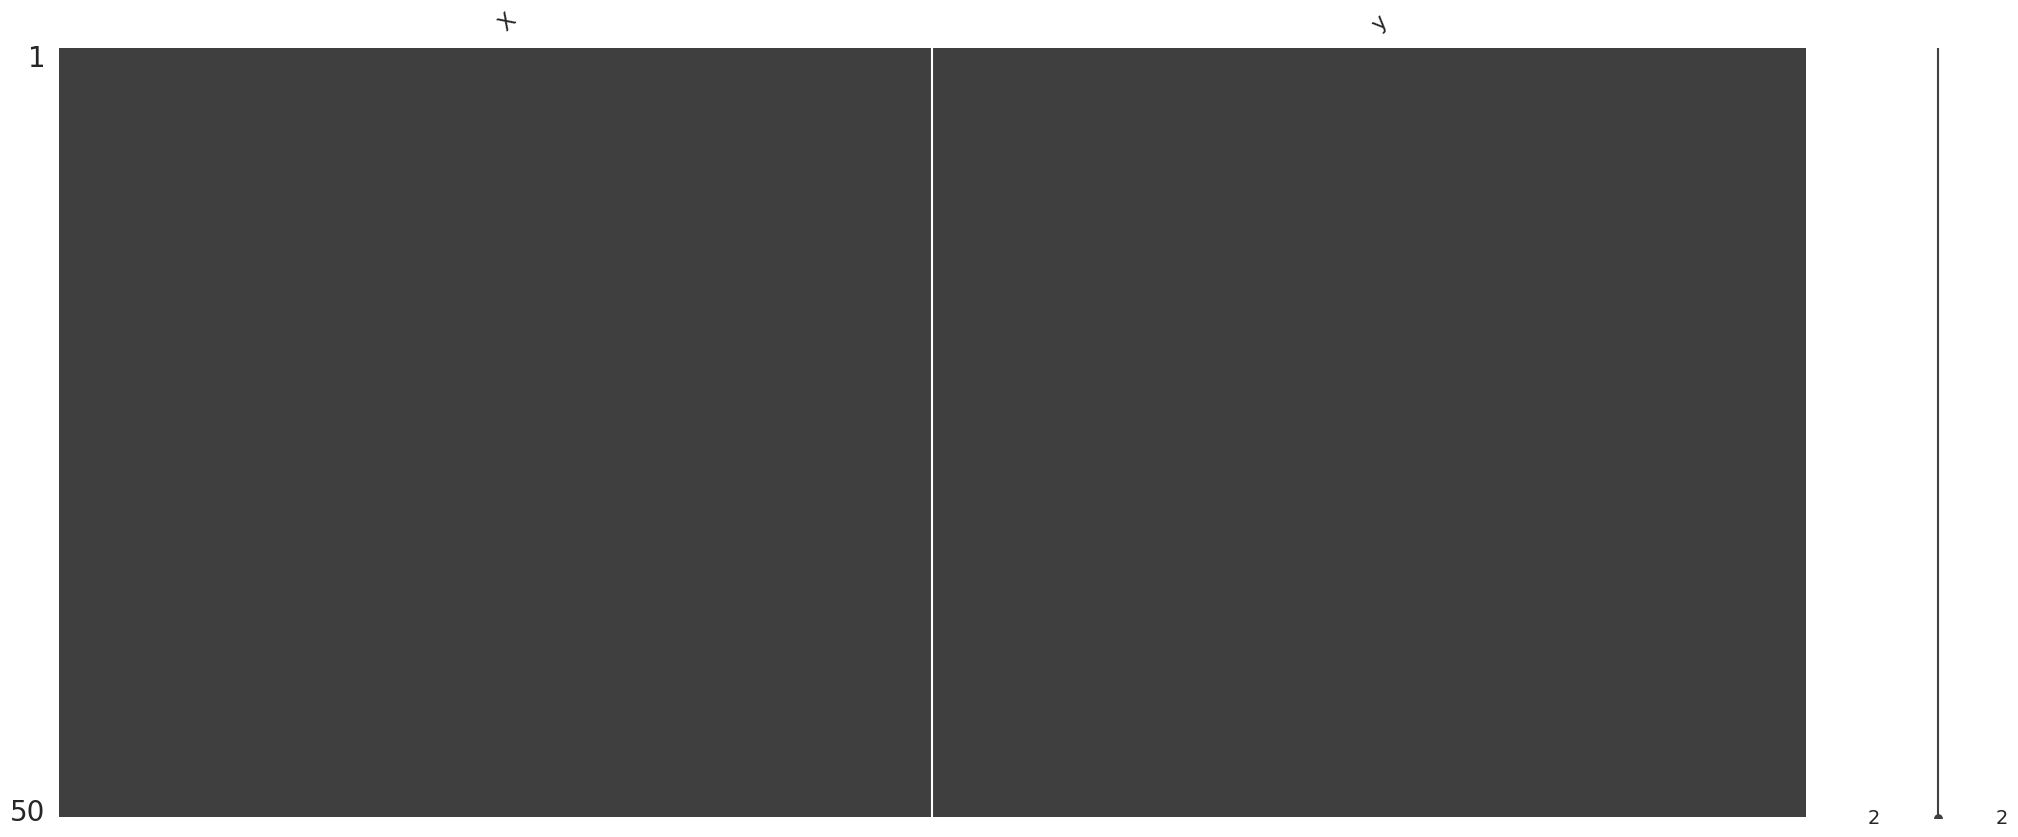

In [346]:
msno.matrix(df3)
plt.show()

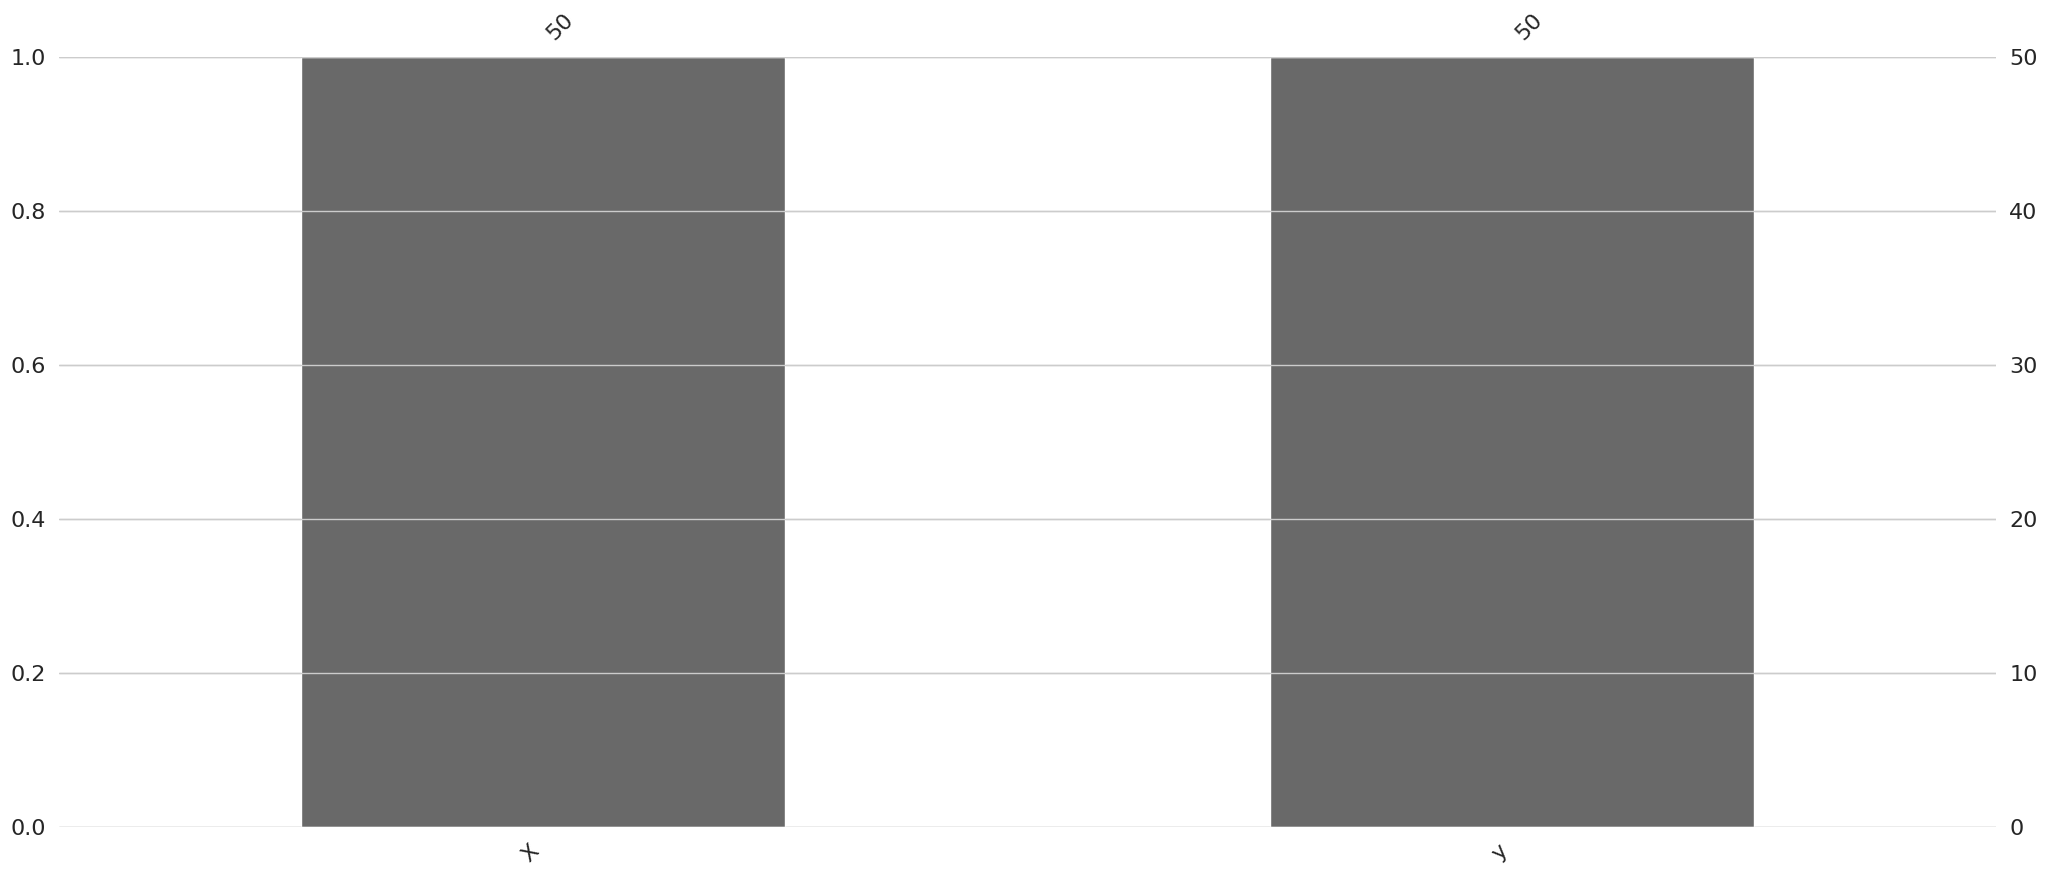

In [347]:
msno.bar(df3)
plt.show()

It is obvious from the above 2 plots that we do not have any missing data.

### 6.2 Analyse models for Dataset-3

> **Note:** Since we have determined through analysis that the data is non-linear, periodic and spread across a wide range of `X` values.We will use the below models to train with the dataset and find the best fit for the dataset.

<ins>Models to train and test:</ins>
- Linear Regression
- Random Forest
- Kernel Ridge Regression
- Support Vector Regression
- Gaussian Process Regression

In [348]:
X3 = df3[['X']]
y3 = df3['y']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# 1. Linear Regression
lr3 = LinearRegression()
evaluate_model(lr3, X3_train, X3_test, y3_train, y3_test, "Linear Regression")

# 2. Random Forest
rf3 = RandomForestRegressor(random_state=42)
evaluate_model(rf3, X3_train, X3_test, y3_train, y3_test, "Random Forest")

# 3. Kernel Ridge Regression
krr3 = make_pipeline(StandardScaler(), KernelRidge(kernel='rbf', alpha=0.1, gamma=0.1))
evaluate_model(krr3, X3_train, X3_test, y3_train, y3_test, "Kernel Ridge (RBF)")

# 4. Support Vector Regression
svr3 = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1, gamma=1))
evaluate_model(svr3, X3_train, X3_test, y3_train, y3_test, "SVR (RBF Kernel)")

# 5. Gaussian Process Regressor
kernel3 = ConstantKernel(1.0, (1e-3, 1e5)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-1)
gpr3 = make_pipeline(StandardScaler(), GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=5, random_state=42))
evaluate_model(gpr3, X3_train, X3_test, y3_train, y3_test, "Gaussian Process")

------------ START ------------

Model: Linear Regression
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.43
R^2 Score: -0.04
------------ END ------------

------------ START ------------

Model: Random Forest
Training time: 0.10 seconds
Prediction time: 0.01 seconds
Mean Squared Error: 0.22
R^2 Score: 0.46
------------ END ------------

------------ START ------------

Model: Kernel Ridge (RBF)
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.43
R^2 Score: -0.04
------------ END ------------

------------ START ------------

Model: SVR (RBF Kernel)
Training time: 0.00 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.34
R^2 Score: 0.17
------------ END ------------

------------ START ------------

Model: Gaussian Process
Training time: 0.34 seconds
Prediction time: 0.00 seconds
Mean Squared Error: 0.10
R^2 Score: 0.76
------------ END ------------



### 6.3 Various model results for Dataset-3

| Model Name | Mean Squared Error | $R^2$ Score | Training Time |
| ---------- | ------------------ | --------- | ------------- |
| Linear Regression | 0.43 | -0.04 | 0.0 |
| Random Forest | 0.22 | 0.46 | 0.13 |
| Kernel Ridge | -0.04 | 0.43 | 0.00 |
| SVR | 0.34 | 0.17 | 0.00 | 
| Gaussian Process | 0.10 | 0.76 | 0.33 |

### 6.4 Final conclusion for Dataset-3 (Best Fit Model)

Dataset 3 is the most challenging of the three due to the `"Curse of Sparsity."` With only 50 data points mapping a complex, noisy, and periodic (wave-like) structure, the risk of `High Variance (Overfitting)` is extreme.

If we were to apply a high-degree polynomial or an unconstrained Decision Tree to this dataset, the model would aggressively memorize the noise and draw wild fluctuations in the empty gaps between our sparse data points.

The below two model performed well with the `Dataset 3` when trained and tested.
- Random Forest
- Gaussian Process

The MSE and $R^2$ Score was better than Random Forest for Gaussian Process Regressor.

The `Gaussian Process Regressor` natively calculates uncertainty `(Standard Deviation),` allowing the model to smoothly interpolate the wave while mathematically acknowledging its uncertainty in the regions where data is missing.

The **`Gaussian Process Regressor`** is the `best fit model for Dataset-3`.

### 6.5 Model Visualization for Dataset 3 (Gaussian Process)

/home/huzefar/Projects/oxford/CML/workspace/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


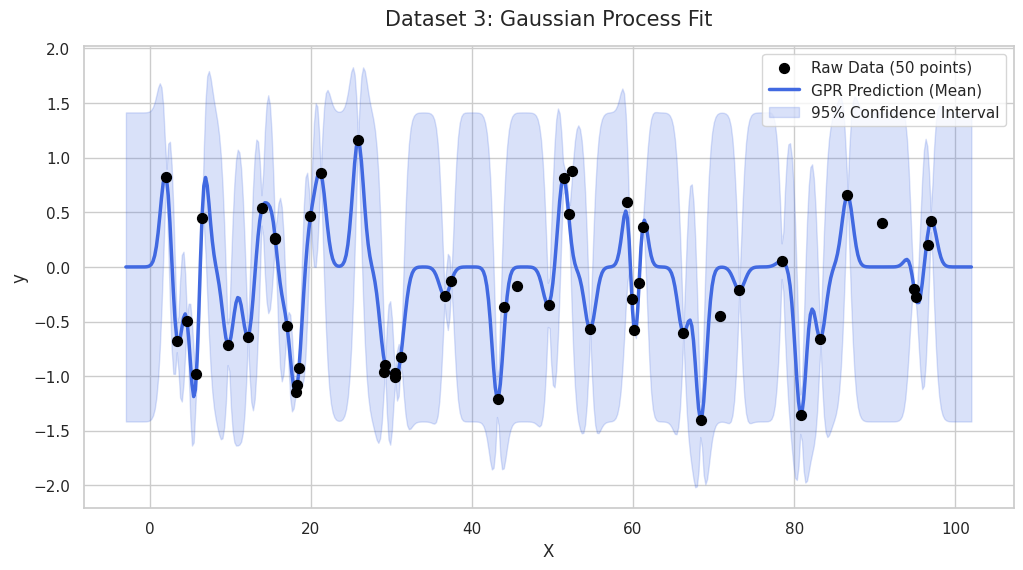

In [349]:
# Generate a smooth range of X values, extending slightly past the min/max of the data
X3_range = np.linspace(df3['X'].min() - 5, df3['X'].max() + 5, 500).reshape(-1, 1)

# Predict using the trained Gaussian Process
y3_pred_smooth, y3_std = gpr3.predict(X3_range, return_std=True)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the raw 50 data points
plt.scatter(df3['X'], df3['y'], color='black', label='Raw Data (50 points)', zorder=3, s=50)

# Plot the GPR Prediction Line
plt.plot(X3_range, y3_pred_smooth, color='royalblue', label='GPR Prediction (Mean)', linewidth=2.5)

# Fill the 95% Confidence Interval (Mean +/- 1.96 * Standard Deviation)
plt.fill_between(
    X3_range.ravel(), 
    y3_pred_smooth - 1.96 * y3_std, 
    y3_pred_smooth + 1.96 * y3_std, 
    color='royalblue', 
    alpha=0.2, 
    label='95% Confidence Interval'
)

# Plot Labels
plt.title("Dataset 3: Gaussian Process Fit", fontsize=15, pad=15)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(loc='upper right', fontsize=11)

plt.show()